## Syncrude MLSB code for monthly data for running from 2020-2022

In [1]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import torch
import torch.optim as optim
import torch.nn as nn
from scipy.interpolate import BSpline

from champ_helpers import *


In [2]:
# np.random.seed(100)
# torch.manual_seed(10)

### Import and create data from Kinetic models

In [3]:
comp = 'Suncor'
df_syncrude = company_data(comp) 

In [4]:
var = 20
year_exp = '2020-2022'
startdate, enddate = year_days(year_exp)
perc = 0.15
diluent_syncrude = np.array(df_syncrude.iloc[0:])[startdate:enddate,1:var] #+ noise*np.random.normal(0,0.005,(366,var))

dim = diluent_syncrude.shape[1]
num_data = diluent_syncrude.shape[0]-1


ch4_mat_full = perc*(np.array(df_syncrude.iloc[0:])[startdate:enddate,21]).reshape(-1,1) #21 for comp
diluent_full = perc*np.array(diluent_syncrude)

print('diluent full shape', diluent_full.shape,'\nShape of full ch4',ch4_mat_full.shape)
    

diluent full shape (1097, 19) 
Shape of full ch4 (1097, 1)


### Import and create data for weather stations

shape of available dataset is (503, 16) 503
shape of interpolated dataset is (1097, 16) 1097


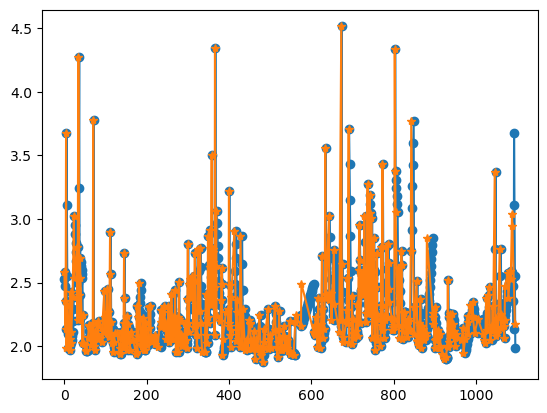

In [5]:
station_wbea = 'Mannix'
dataset_true, xdays_true = station(station_wbea,year_exp)
print('shape of available dataset is',dataset_true.shape,len(xdays_true))

interpolate = True
if interpolate == True:
    x = np.array(xdays_true)
    y = np.zeros([dataset_true.shape[0],dataset_true.shape[1]])
    xx = np.linspace(0,diluent_full.shape[0]-1,diluent_full.shape[0])
    dataset_inter = np.zeros((diluent_full.shape[0],dataset_true.shape[1]))
    for i in range(dataset_true.shape[1]):
        y[:,i] = np.array(dataset_true)[:,i]
#         dataset_inter[:,i] = np.interp(xx, x, y[:,i])
    spl = BSpline(x, y, 1,extrapolate = 'periodic')
    dataset_inter = spl(xx) 
    
    dataset = dataset_inter
    xdays = list(np.arange(len(xx))[:])
else:
    dataset = dataset_true
    xdays = xdays_true

print('shape of interpolated dataset is',dataset.shape,len(xdays))

plt.plot(dataset[:,0],'-o',label = 'interpolated')
plt.plot(xdays_true,dataset_true[:,0],'-*',label = 'true')


Import the dataset for MLSB and create input-output pairs

(1097, 19)
torch.Size([1097, 15])


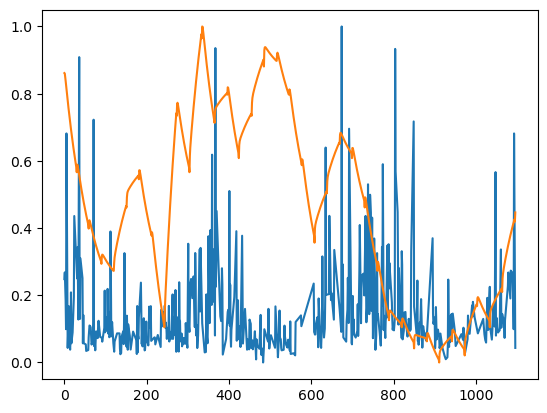

In [6]:
#import data from csv files
year_start = 0
years_end = len(xdays)
percentage = 1.0

diluent = diluent_full[xdays,:]
print(diluent_full.shape)
wbea_pars = dataset[year_start:years_end,1:]
ch4_wbea = dataset[year_start:years_end,0]
ch4_mat = percentage*ch4_mat_full[xdays,:].astype('float32')


#create input data
inp = torch.from_numpy(wbea_pars.astype('float32'))
input_data = percentage*torch.concatenate((inp,torch.tensor(diluent.astype('float32'))),dim = 1) # uses real or 2nd gen diluent data
print(inp.shape)


inp_min = torch.min(input_data,dim=0)[0]
inp_max = torch.max(input_data,dim=0)[0]
input_data = (input_data - inp_min)/(inp_max-inp_min)


#create output data for concentrations taken from real data from WBEA
ch4_conc_data = percentage*torch.from_numpy(ch4_wbea.reshape(-1,1).astype('float32')).reshape(-1,1)

    

out_min = torch.min(ch4_conc_data)
out_max = torch.max(ch4_conc_data)
ch4_conc_data = (ch4_conc_data - out_min)/(out_max-out_min)
plt.plot(ch4_conc_data)

ch4_emm_data = percentage*torch.Tensor(ch4_mat).reshape(-1,1) 
scale_emm_data = torch.norm(ch4_emm_data)
ch4_min = torch.min(ch4_emm_data)
ch4_max = torch.max(ch4_emm_data)
ch4_emm_data = (ch4_emm_data - ch4_min)/(ch4_max-ch4_min)
plt.plot(ch4_emm_data)


In [7]:
#create train-test split

num_train = int(0.8*input_data.shape[0])
num_val = int(0.2*(input_data.shape[0]))


input_train = input_data[:num_train,:]            # contains WBEA variables and lab HCs
ch4_conc_train = ch4_conc_data[:num_train,:]      # from WBEA
ch4_emm = ch4_emm_data[:num_train,:] 


input_val = input_data[num_train:num_train+num_val, :]            
ch4_conc_val = ch4_conc_data[num_train:num_train+num_val, :] 
ch4_emm_val = ch4_emm_data[num_train:num_train+num_val, :] 



print(input_train.shape, ch4_conc_train.shape, ch4_emm.shape)
print(input_val.shape, ch4_conc_val.shape, ch4_emm_val.shape)


torch.Size([877, 34]) torch.Size([877, 1]) torch.Size([877, 1])
torch.Size([219, 34]) torch.Size([219, 1]) torch.Size([219, 1])


In [8]:
# Create time data
time_data = np.array(xdays).reshape(-1,1) 
# Convert time_data to a PyTorch tensor and normalize
time_data = torch.tensor(time_data, dtype=torch.float32)
t_min = torch.min(time_data)
t_max = torch.max(time_data)
time_data  /=t_max

time_train, time_val = time_data[:num_train], time_data[num_train:num_train+num_val]

In [9]:
print(time_data.shape, time_train.shape, time_val.shape)

torch.Size([1097, 1]) torch.Size([877, 1]) torch.Size([219, 1])


In [10]:
num_data_train = input_train.shape[0] # number of data points for training data set
num_data_tot = num_data_train

d = int(input_train.shape[1]) # 

In [11]:
input_train = input_train.requires_grad_(True)
input_val = input_val.requires_grad_(True)
time_train = time_train.requires_grad_(True)
time_val = time_val.requires_grad_(True)

### The next few cells contain different models to train. Whichever models you want to use, please uncomment that and run it for training.

# LSTM

In [12]:
# # LSTM

# input_dim = d
# neurons = 100
# n_dims = 2
# n_dims1 = d+1
# class Net(nn.Module):
#     def __init__(self):
#         super(Net,self).__init__()
#         self.lstm = nn.LSTM(input_dim, neurons,4)
#         self.out = nn.Linear(neurons, n_dims)
#         self.lin4 = nn.Linear(n_dims1,neurons,bias = True)
#         self.lin5 = nn.Linear(neurons,neurons,bias = True)
#         self.lin6 = nn.Linear(neurons,neurons,bias = True)
#         self.lin7 = nn.Linear(neurons,n_dims,bias = True)

#     def forward(self, x,t):
#         y,_ = self.lstm(x[:,:])
#         y = self.out(y).abs()
#         ch4_conc = y[:,0].reshape(-1,1)
#         ch4_emm = y[:,1].reshape(-1,1)
# #         data_conc = torch.cat((ch4_conc,x[:,:]),dim = 1)
# #         z = self.lin4(data_conc).sin()
# #         z = self.lin5(z).relu()
# #         z = self.lin6(z).relu()
# #         ch4_emm = self.lin7(z)
#         return ch4_conc,ch4_emm

# net = Net()

# net = Net()
# # Loss function and optimizer
# criterion1 = nn.MSELoss()
# optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9,weight_decay=0.001)
# # optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

# # Training loop
# epochs=10000
# for epoch in range(epochs):
#     optimizer.zero_grad()

#     ch4_conc_out, ch4_emm_out = net(input_train, time_train)

#     # Compute loss
#     loss1 = criterion1(ch4_conc_out, ch4_conc_train)
#     loss2 = criterion1(ch4_emm_out, ch4_emm)
#     loss = loss1 + loss2
#     loss.backward()
#     optimizer.step()

#     if epoch % 1000 == 0:
#         print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.10f}, Loss1: {loss1.item():.10f}, Loss2: {loss2.item():.10f}')

# print(ch4_emm.shape)

# REVERSE

In [13]:
# input_dim = d
# neurons = 500
# neurons2 = 200
# n_dims = 1
# n_dims1 = d+1-19 #20+1
# class Net(nn.Module):
#     def __init__(self):
#         super(Net,self).__init__()
        
#         self.lin1 = nn.Linear(input_dim,neurons,bias = True)
#         self.lin2 = nn.Linear(neurons,neurons,bias = True)
#         self.lin22 = nn.Linear(neurons,neurons,bias = True)
#         self.lin222 = nn.Linear(neurons,neurons,bias = True)
#         self.lin3 = nn.Linear(neurons,n_dims,bias = True)
#         self.lin4 = nn.Linear(n_dims1,neurons2,bias = True)
#         self.lin5 = nn.Linear(neurons2,neurons2,bias = True)
#         self.lin6 = nn.Linear(neurons,neurons,bias = True)
#         self.lin7 = nn.Linear(neurons2,n_dims,bias = True)
        
#     def forward(self, x,t):
#         y = self.lin1(x[:,:]).relu()
#         y = self.lin2(y).relu()
#         y = self.lin3(y)
#         ch4_conc = y.abs()
# #         min_x = torch.min(ch4_conc1)
# #         max_x = torch.max(ch4_conc1)
# #         ch4_conc = (ch4_conc1-ch4_min)/(ch4_max-ch4_min)

#         data_conc = torch.cat((ch4_conc,x[:,:15]),dim = 1)
# #         data_conc = torch.cat((ch4_emm,x[:,15:]),dim = 1)

#         z = self.lin4(data_conc).relu()
#         z = self.lin5(z).relu()
#         z = self.lin7(z)
#         ch4_emm = z.abs()
# #         ch4_conc = z.relu()
#         return ch4_conc,ch4_emm

# net = Net()
# # net.lin1.weight.requires_grad = False
# # net.lin1.bias.requires_grad = False
# # net.lin4.weight.requires_grad = False
# # net.lin4.bias.requires_grad = False
# # net.lin1.weight.requires_grad = False
# # Loss function and optimizer
# criterion1 = nn.MSELoss()
# optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9,weight_decay=0.001)
# # optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

# # Training loop
# epochs=10000
# for epoch in range(epochs):
#     optimizer.zero_grad()

#     ch4_conc_out, ch4_emm_out = net(input_train, time_train)

#     # Compute loss
#     loss1 = criterion1(ch4_conc_out, ch4_conc_train)
#     loss2 = criterion1(ch4_emm_out, ch4_emm)
#     loss = loss1 + loss2
#     loss.backward()
#     optimizer.step()

#     if epoch % 1000 == 0:
#         print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.10f}, Loss1: {loss1.item():.10f}, Loss2: {loss2.item():.10f}')

# print(ch4_emm.shape)

# NN

In [14]:
# input_dim = d
# neurons = 500
# n_dims = 2
# n_dims1 = d+1-15 #20+1
# class Net(nn.Module):
#     def __init__(self):
#         super(Net,self).__init__()
        
#         self.lin1 = nn.Linear(input_dim,neurons,bias = True)
#         self.lin2 = nn.Linear(neurons,neurons,bias = True)
#         self.lin22 = nn.Linear(neurons,neurons,bias = True)
#         self.lin222 = nn.Linear(neurons,neurons,bias = True)
#         self.lin3 = nn.Linear(neurons,n_dims,bias = True)
#         self.lin4 = nn.Linear(n_dims1,neurons,bias = True)
#         self.lin5 = nn.Linear(neurons,neurons,bias = True)
#         self.lin6 = nn.Linear(neurons,neurons,bias = True)
#         self.lin7 = nn.Linear(neurons,n_dims,bias = False)
        
#     def forward(self, x,ch4):
#         y = self.lin1(x[:,:]).relu()
#         y = self.lin22(y).relu()
#         y = self.lin222(y).relu()
#         y = self.lin2(y).relu()
#         y = self.lin3(y).abs()
#         ch4_conc = y[:,0].reshape(-1,1)
#         ch4_emm = y[:,1].reshape(-1,1)
#         return ch4_conc,ch4_emm

# net = Net()
# # Loss function and optimizer
# criterion1 = nn.MSELoss()
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9,weight_decay=0.001)
# # optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

# # Training loop
# epochs=10000
# for epoch in range(epochs):
#     optimizer.zero_grad()

#     ch4_conc_out, ch4_emm_out = net(input_train, time_train)

#     # Compute loss
#     loss1 = criterion1(ch4_conc_out, ch4_conc_train)
#     loss2 = criterion1(ch4_emm_out, ch4_emm)
#     loss = loss1 + loss2
#     loss.backward()
#     optimizer.step()

#     if epoch % 1000 == 0:
#         print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.10f}, Loss1: {loss1.item():.10f}, Loss2: {loss2.item():.10f}')

# print(ch4_emm.shape)

# RNN_mod

In [15]:
# import torch
# import torch.nn as nn
# import torch.optim as optim

# # Assuming these variables are defined elsewhere in your code
# input_dim = d
# neurons = 500
# n_dims = 1

# # Define the neural network architecture
# class Net(nn.Module):
#     def __init__(self):
#         super(Net, self).__init__()
#         self.lin1 = nn.Linear(input_data.size(1)+1, neurons, bias=True)
#         self.lin2 = nn.Linear(neurons, neurons, bias=True)
#         self.lin22 = nn.Linear(neurons, neurons, bias=True)
#         self.lin222 = nn.Linear(neurons, neurons, bias=True)
#         self.lin3 = nn.Linear(neurons, n_dims, bias=True)
        
#         self.lin4 = nn.Linear(1, neurons, bias=True)
#         self.lin44 = nn.Linear(neurons, 1, bias=True)
#         self.lin5 = nn.Linear(neurons, 1, bias=False)
        
# #         self.lin6 = nn.Linear(1, neurons, bias=True) 
# #         self.lin7 = nn.Linear(neurons, neurons, bias=True)
# #         self.lin8 = nn.Linear(neurons, n_dims, bias=True)
        
# #         self.activation1 = nn.ELU()  

#     def forward(self, x, t):
    
#         # Concatenate time with input data
#         x_with_time = torch.cat((x[:,:], t), dim=1)
        
#         y = self.lin1(x_with_time).relu()
#         y = self.lin2(y).relu()
#         y = self.lin22(y).relu()
# #         y = self.lin222(y).relu()
    
#         ch4_conc = self.lin3(y).abs()

#         z = self.lin4(ch4_conc).relu()
#         z = self.lin44(z).abs()
#         ch4_emm = z

#         return ch4_conc, ch4_emm

# # Initialize the neural network
# net = Net()

# # Loss function and optimizer
# criterion1 = nn.MSELoss()
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9,weight_decay=0.001)
# # optimizer = torch.optim.Adam(net.parameters(), lr=1e-4) #,weight_decay=0.001)
# # optimizer = torch.optim.Adagrad(net.parameters(),lr=0.001, lr_decay=0, weight_decay=0.5)
# # net.lin1.weight.requires_grad = False
# # net.lin1.bias.requires_grad = False
# # net.lin4.weight.requires_grad = False
# # net.lin4.bias.requires_grad = False
# # Training loop
# epochs=10000
# for epoch in range(epochs):
#     optimizer.zero_grad()

#     ch4_conc_out, ch4_emm_out = net(input_train, time_train)

#     # Compute loss
#     loss1 = criterion1(ch4_conc_out, ch4_conc_train)
#     loss2 = criterion1(ch4_emm_out, ch4_emm)
#     loss = loss1 + loss2
#     loss.backward()
#     optimizer.step()

#     if epoch % 1000 == 0:
#         print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.10f}, Loss1: {loss1.item():.10f}, Loss2: {loss2.item():.10f}')

# print(ch4_emm.shape)

# POLYNOMIAL GRADIENT

In [16]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from numpy import matlib

# for i in range(1):
#     print('starting simulation number',i)# Assuming these variables are defined elsewhere in your code
#     input_dim = input_data.size(1)
#     neurons = 200
#     neurons2 = 500
#     n_dims = 1
#     dict_shape = int((d+1+1-19)*(d+1+2-19)/2) #14 or 19
#     print(dict_shape)

#     # Define the neural network architecture
#     class Net(nn.Module):
#         def __init__(self):
#             super(Net, self).__init__()
#             self.lin1 = nn.Linear(input_data.size(1)+1, neurons, bias=True)
#             self.lin2 = nn.Linear(neurons, neurons, bias=True)
#             self.lin22 = nn.Linear(neurons, neurons, bias=True)
#             self.lin222 = nn.Linear(neurons, neurons, bias=True)
#             self.lin3 = nn.Linear(neurons, n_dims, bias=True)

#             self.lin4 = nn.Linear(input_data.size(1)+1, neurons2, bias=True)
#             self.lin44 = nn.Linear(neurons2, neurons2, bias=True)
#             self.lin5 = nn.Linear(neurons2, 1, bias=False)
            
#             self.dictlin = nn.Linear(dict_shape, 1, bias=False)

#     #         self.lin6 = nn.Linear(1, neurons, bias=True) 
#     #         self.lin7 = nn.Linear(neurons, neurons, bias=True)
#     #         self.lin8 = nn.Linear(neurons, n_dims, bias=True)

#     #         self.activation1 = nn.ELU()  

#         def forward(self, x, t):

#             # Concatenate time with input data
#             x_with_time = torch.cat((x[:,:], t), dim=1)

#             y = self.lin1(x_with_time).tanh()
#             y = self.lin2(y).tanh()
#             y = self.lin22(y).tanh()
#     #         y = self.lin222(y).relu()

#             ch4_conc = self.lin3(y).abs()

#             # Compute the gradient of ch4_conc with respect to time
#             ch4_conc_derivative = torch.autograd.grad(outputs=ch4_conc, inputs=t, grad_outputs=torch.ones_like(ch4_conc), create_graph=True)[0]

#             z = torch.cat((ch4_conc,x[:,:15]),dim = 1)
# #             z = x[:,:15]
#             grad_J = dictionarypoly(z.detach().numpy(),'2')
#             grad_J = self.dictlin(grad_J).abs()

#     #         print(grad_J.shape)

#             if ch4_conc_derivative is None:
#                 ch4_conc_derivative = torch.zeros_like(t)

#             # Add ch4_conc_derivative to input x
#             x_with_derivative = ch4_conc_derivative + grad_J

#             ch4_emm = x_with_derivative.abs()
# #             ch4_emm = grad_J

#             return ch4_conc, ch4_emm

#     # Initialize the neural network
#     net = Net()
#     print(torch.norm(net.lin1.weight.detach()),torch.norm(net.lin2.weight.detach()),torch.norm(net.lin5.weight.detach()))

#     # Loss function and optimizer
#     criterion1 = nn.MSELoss()
#     optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9,weight_decay=0.001)
# #     optimizer = torch.optim.Adam(net.parameters(), lr=1e-4) #,weight_decay=0.001)
# #     optimizer = torch.optim.Adagrad(net.parameters(),lr=0.001, lr_decay=0, weight_decay=0.5)
 
#     epochs=10000
#     for epoch in range(epochs):
#         optimizer.zero_grad()

#         ch4_conc_out, ch4_emm_out = net(input_train, time_train)

#         # Compute loss
#         loss1 = criterion1(ch4_conc_out, ch4_conc_train)
#         loss2 = criterion1(ch4_emm_out, ch4_emm)
#         loss = loss1 + loss2

#         loss.backward()
#         optimizer.step()
#         with torch.no_grad():
#             for i in range(net.dictlin.weight.shape[1]):
#                 if torch.abs(net.dictlin.weight[0,i])<=1e-04:
# #                     print(net.dictlin.weight[0,i])
#                     net.dictlin.weight[0,i] = 0

#         if epoch % 1000 == 0:
#             print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.10f}, Loss1: {loss1.item():.10f}, Loss2: {loss2.item():.10f}')

#     print(ch4_emm.shape,torch.norm(net.lin1.weight.detach()),torch.norm(net.lin2.weight.detach()),torch.norm(net.lin5.weight.detach()))

# FORWARD

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

for i in range(1):
    print('starting simulation number',i)# Assuming these variables are defined elsewhere in your code
    input_dim = d
    neurons = 500
    neurons2 = 200
    n_dims = 1

    # Define the neural network architecture
    class Net(nn.Module):
        def __init__(self):
            super(Net, self).__init__()
            self.lin1 = nn.Linear(input_data.size(1)+1, neurons, bias=True)
            self.lin2 = nn.Linear(neurons, neurons, bias=True)
            self.lin22 = nn.Linear(neurons, neurons, bias=True)
            self.lin222 = nn.Linear(neurons, neurons, bias=True)
            self.lin3 = nn.Linear(neurons, n_dims, bias=True)

            self.lin4 = nn.Linear(input_data.size(1)+1-19, neurons2, bias=True)
            self.lin44 = nn.Linear(neurons2, neurons2, bias=True)
            self.lin5 = nn.Linear(neurons2, 1, bias=True)

        def forward(self, x, t):

            # Concatenate time with input data
            x_with_time = torch.cat((x[:,:], t), dim=1)

            y = self.lin1(x_with_time).tanh()
            y = self.lin2(y).tanh()
            y = self.lin22(y).tanh()
    #         y = self.lin222(y).relu()

            ch4_conc = self.lin3(y).abs()

            # Compute the gradient of ch4_conc with respect to time
            ch4_conc_derivative = torch.autograd.grad(outputs=ch4_conc, inputs=t, grad_outputs=torch.ones_like(ch4_conc), create_graph=True)[0]

   
            z = torch.cat((ch4_conc,x[:,:15]),dim = 1)
            z = self.lin4(z).tanh()
            z = self.lin44(z).tanh()
            grad_J = self.lin5(z).abs()

   
            if ch4_conc_derivative is None:
                ch4_conc_derivative = torch.zeros_like(t)

            # Add ch4_conc_derivative to input x
            x_with_derivative = ch4_conc_derivative + grad_J

            ch4_emm = x_with_derivative.abs()

            return ch4_conc, ch4_emm

    # Initialize the neural network
    net = Net()
    print(torch.norm(net.lin1.weight.detach()),torch.norm(net.lin2.weight.detach()),torch.norm(net.lin5.weight.detach()))

    # Loss function and optimizer
    criterion1 = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9,weight_decay=0.001)
#     optimizer = torch.optim.Adam(net.parameters(), lr=1e-4) #,weight_decay=0.001)
#     optimizer = torch.optim.Adagrad(net.parameters(),lr=0.001, lr_decay=0, weight_decay=0.5)
   
    # Training loop
    epochs=10000
    for epoch in range(epochs):
        optimizer.zero_grad()

        ch4_conc_out, ch4_emm_out = net(input_train, time_train)

        # Compute loss
        loss1 = criterion1(ch4_conc_out, ch4_conc_train)
        loss2 = criterion1(ch4_emm_out, ch4_emm)
        loss = loss1 + loss2
        loss.backward()
        optimizer.step()

        if epoch % 1000 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.10f}, Loss1: {loss1.item():.10f}, Loss2: {loss2.item():.10f}')

    print(ch4_emm.shape,torch.norm(net.lin1.weight.detach()),torch.norm(net.lin2.weight.detach()),torch.norm(net.lin5.weight.detach()))

starting simulation number 0
tensor(12.9761) tensor(12.9100) tensor(0.5567)
Epoch [0/10000], Loss: 0.2842348516, Loss1: 0.0313712619, Loss2: 0.2528635859
Epoch [1000/10000], Loss: 0.0230672956, Loss1: 0.0111477431, Loss2: 0.0119195534
Epoch [2000/10000], Loss: 0.0126785934, Loss1: 0.0090439487, Loss2: 0.0036346442
Epoch [3000/10000], Loss: 0.0130394166, Loss1: 0.0087275328, Loss2: 0.0043118838
Epoch [4000/10000], Loss: 0.0140135428, Loss1: 0.0086321393, Loss2: 0.0053814035
Epoch [5000/10000], Loss: 0.0131681822, Loss1: 0.0085677486, Loss2: 0.0046004341
Epoch [6000/10000], Loss: 0.0134087242, Loss1: 0.0085497173, Loss2: 0.0048590074
Epoch [7000/10000], Loss: 0.0133352177, Loss1: 0.0085510155, Loss2: 0.0047842022
Epoch [8000/10000], Loss: 0.0132150864, Loss1: 0.0085546868, Loss2: 0.0046603996
Epoch [9000/10000], Loss: 0.0133380322, Loss1: 0.0085661504, Loss2: 0.0047718817
torch.Size([877, 1]) tensor(5.0887) tensor(5.0418) tensor(0.6551)


In [18]:
conc_check, emm_check  = net(input_train, time_train)

error_conc = torch.norm(conc_check-ch4_conc_train)/torch.norm(ch4_conc_train)
error_emm = torch.norm(emm_check-ch4_emm)/torch.norm(ch4_emm)
# error_emm_cumm = torch.norm((emm_cumm_train)-ch4_mat_cumm_train)/torch.norm(ch4_mat_cumm_train)
print('training concentration error',error_conc.item(), '\ntraining emmisions error',error_emm.item())

training concentration error 0.47808772325515747 
training emmisions error 0.1163906380534172


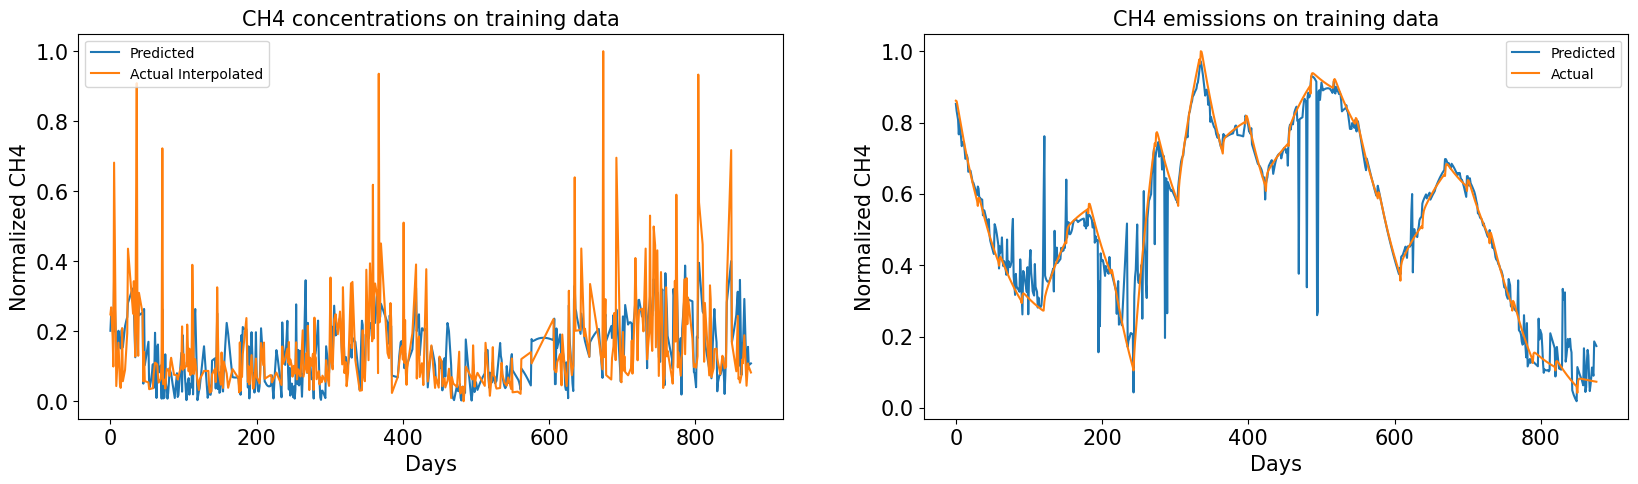

In [19]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(conc_check.detach().numpy(), label='Predicted')
plt.plot(ch4_conc_train.numpy(), label='Actual Interpolated')
plt.legend()
plt.tick_params(axis='both', labelsize=15)
plt.xlabel('Days',fontsize=15)
plt.ylabel('Normalized CH4',fontsize=15)
plt.title('CH4 concentrations on training data',fontsize=15)
 
plt.subplot(1,2,2)
plt.plot(emm_check.detach().numpy()[:], label='Predicted')
plt.plot(ch4_emm.numpy()[:], label='Actual')
plt.legend()
plt.tick_params(axis='both', labelsize=15)
plt.xlabel('Days',fontsize=15)
plt.ylabel('Normalized CH4',fontsize=15)
plt.title('CH4 emissions on training data',fontsize=15)

# plt.legend()
plt.show()

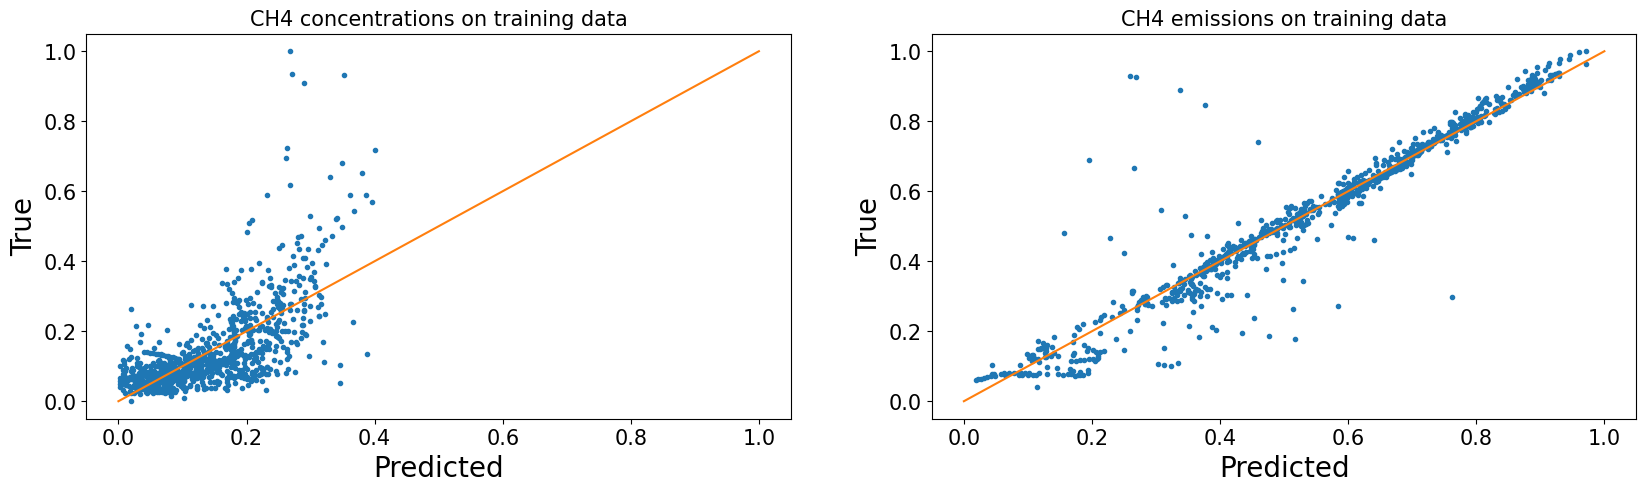

In [20]:
x = np.linspace(0,1,300)

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(conc_check.detach().numpy(),ch4_conc_train.numpy(),'.')
plt.plot(x,x)
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('True',fontsize=20)
plt.tick_params(axis='both', labelsize=15)
plt.title('CH4 concentrations on training data',fontsize=15)


plt.subplot(1,2,2)
plt.plot(emm_check.detach().numpy(),ch4_emm.numpy(),'.')
plt.plot(x,x)
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('True',fontsize=20)
plt.tick_params(axis='both', labelsize=15)
plt.title('CH4 emissions on training data',fontsize=15)


plt.show()

In [21]:
#validation check
conc_check_val, emm_check_val = net(input_val, time_val) #,time[num_train:,:])

error_conc_val = torch.norm(conc_check_val-ch4_conc_val)/torch.norm(ch4_conc_val)

error_emm_val = torch.norm(emm_check_val-ch4_emm_val)/torch.norm(ch4_emm_val)

print('validation concentration error',error_conc_val.item(), '\nvalidation emisions error',error_emm_val.item())

validation concentration error 0.6493996381759644 
validation emisions error 1.0954937934875488


Text(0.5, 1.0, 'CH4 emissions on validation data')

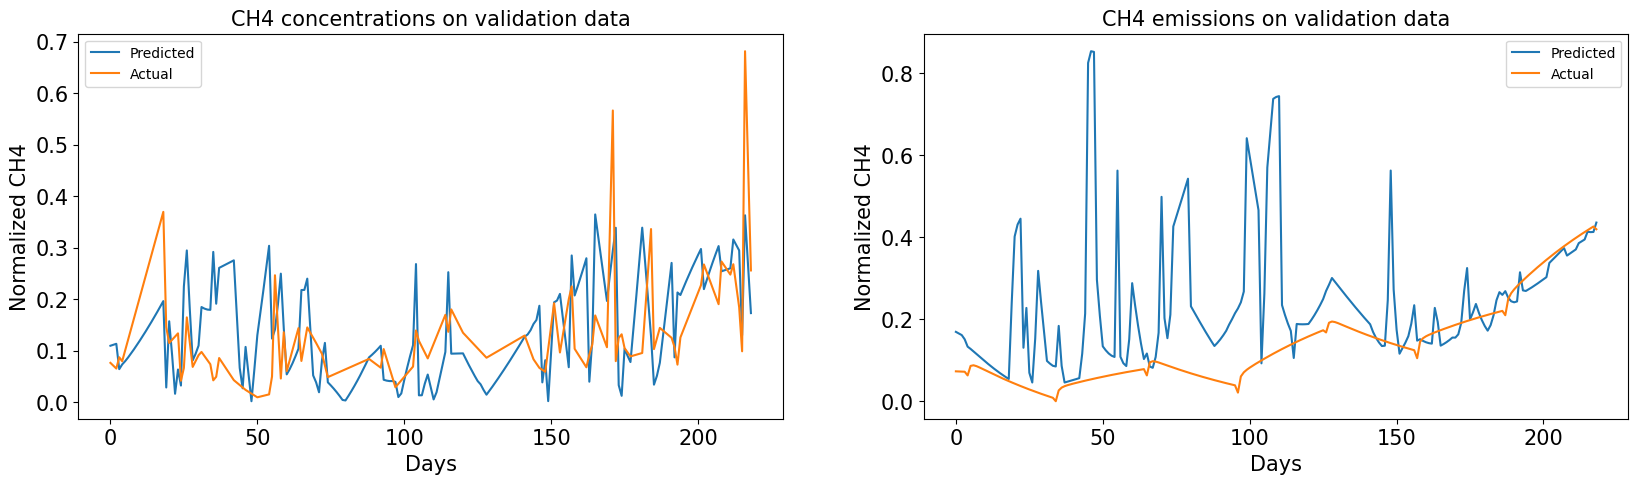

In [22]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(conc_check_val.detach().numpy(), label='Predicted')
plt.plot(ch4_conc_val.numpy(), label='Actual')
plt.legend()
plt.xlabel('Days',fontsize=15)
plt.ylabel('Normalized CH4',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.title('CH4 concentrations on validation data',fontsize=15)

plt.subplot(1,2,2)
plt.plot(emm_check_val.detach().numpy(), label='Predicted')
plt.plot(ch4_emm_val.numpy(), label='Actual')
plt.legend()
plt.xlabel('Days',fontsize=15)
plt.ylabel('Normalized CH4',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
# plt.ylim(0.8,1.05)
plt.title('CH4 emissions on validation data',fontsize=15)

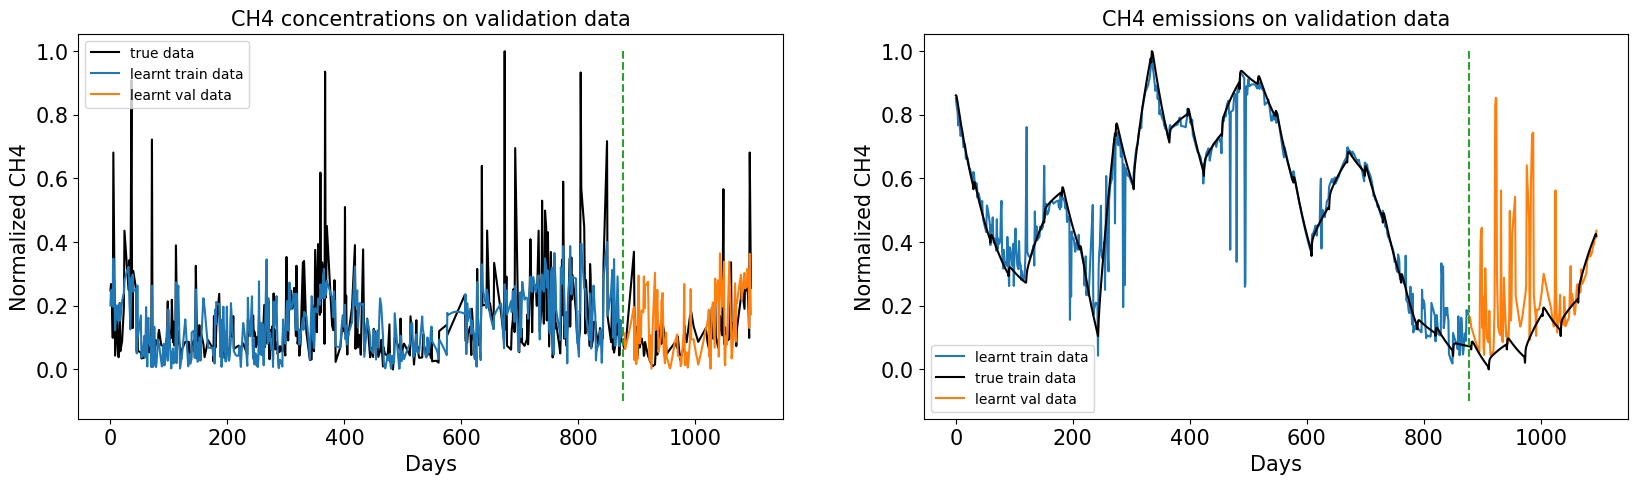

In [23]:

days = np.array(xdays) #np.linspace(0,input_data.shape[0],input_data.shape[0])
# days = np.array(xx) #np.linspace(0,input_data.shape[0],input_data.shape[0])
days_train = days[:num_train]
days_val = days[num_train:num_train+num_val]
# print(days)
vert_x = int(xdays[num_train])*np.ones(100)
vert_y = np.linspace(-0.1,1,100)
# days_val = days[num_train:]

plt.figure(figsize=(20,5))
plt.subplot(1,2,2)
plt.plot(days_train,emm_check.detach().numpy(),label = 'learnt train data')
plt.plot(days_train,ch4_emm.numpy(),'k',label = 'true train data')
plt.plot(days_val,emm_check_val.detach().numpy(),label = 'learnt val data')
plt.plot(days_val,ch4_emm_val.numpy(),'k')
plt.plot(vert_x,vert_y,'--')
plt.xlabel('Days',fontsize=15)
plt.ylabel('Normalized CH4',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.legend()
plt.title('CH4 emissions on validation data',fontsize=15)


plt.subplot(1,2,1)
plt.plot(days_train,ch4_conc_train.numpy(),'k',label = 'true data')
plt.plot(days_train,conc_check.detach().numpy(),label = 'learnt train data')
plt.plot(days_val,ch4_conc_val.numpy(),'k')
plt.plot(days_val,conc_check_val.detach().numpy(),label = 'learnt val data')
plt.plot(vert_x,vert_y,'--')
plt.xlabel('Days',fontsize=15)
plt.ylabel('Normalized CH4',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.title('CH4 concentrations on validation data',fontsize=15)


plt.legend()
plt.show()